# descriptive.ipynb

This notebook calculated descriptive statistics in detail. The main notebook reports just a summary.

The `display_summary_table` and `plot_descriptive` functions below are called from the main notebook.

<br>
<br>

In [1]:
from IPython.display import display,Markdown #,HTML
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import pandas as pd


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'{s}<br><br>'
    else:
        s = f'<br><br>{s}'
    display( Markdown(s) )



Below the previously developed `parse_data.ipynb` notebook is run. See that notebook for details.

In [2]:
%run parse_data.ipynb

df.describe()

Straightlining in line 48
Straightlining in line 78
Straightlining in line 151
Straightlining in line 392
Straightlining in line 465
Straightlining in line 563
Straightlining in line 665


,Gender,Status,Income,P,SC,SI,NE,H,IBB
count,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000,803.000000
mean,0.682441,0.251557,2.806974,2.326588,2.946866,2.349315,3.424159,3.498132,2.751868
std,0.465817,0.434178,1.847382,1.116592,0.860738,0.990528,0.890439,0.832905,0.878709
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,1.000000,2.333333,1.500000,2.800000,3.000000,2.000000
50%,1.000000,0.000000,2.000000,2.000000,3.000000,2.166667,3.400000,3.750000,2.750000
75%,1.000000,1.000000,4.000000,3.250000,3.666667,3.000000,4.000000,4.000000,3.500000
max,1.000000,1.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


To create a custom display of descriptive statistics, let's first define functions that will calculate central tendency and dispersion metrics.

Refer also to [this notebook](https://github.com/0todd0000/OpenBook-DataAnalysisPracticeInPythonAndJupyter/blob/master/Lessons/Lesson04/5-Examples/DescriptiveStatsExamples.ipynb) for details regarding how create custom descriptive statistics tables.

In [3]:
def central(x, print_output=True):
    x0     = np.mean( x )
    x1     = np.median( x )
    x2     = stats.mode( x ).mode
    return x0, x1, x2


def dispersion(x, print_output=True):
    y0 = np.std( x ) # standard deviation
    y1 = np.min( x )  # minimum
    y2 = np.max( x )  # maximum
    y3 = y2 - y1      # range
    y4 = np.percentile( x, 25 ) # 25th percentile (i.e., lower quartile)
    y5 = np.percentile( x, 75 ) # 75th percentile (i.e., upper quartile)
    y6 = y5 - y4 # inter-quartile range
    return y0,y1,y2,y3,y4,y5,y6

<br>

Let's now assemble and display a central tendency table:

</br>

In [4]:
def display_central_tendency_table(num=1):
    display_title('Central tendency summary statistics.', pref='Table', num=num, center=False)
    df_central = df.apply(lambda x: central(x), axis=0)
    round_dict = {'Gender': 3, 'Status': 3, 'Income': 3, 'P': 3, 'SC': 3, 'SI': 3,'NE': 3, 'H': 3, 'IBB': 3}
    df_central = df_central.round( round_dict )
    row_labels = 'mean', 'median', 'mode'
    df_central.index = row_labels
    display( df_central )

display_central_tendency_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,Gender,Status,Income,P,SC,SI,NE,H,IBB
mean,0.682,0.252,2.807,2.327,2.947,2.349,3.424,3.498,2.752
median,1.000,0.000,2.000,2.000,3.000,2.167,3.400,3.750,2.750
mode,1.000,0.000,1.000,1.000,3.000,2.000,3.000,4.000,2.000


<br>

Let's repeat for a dispersion table:

</br>

In [5]:
def display_dispersion_table(num=1):
    display_title('Dispersion summary statistics.', pref='Table', num=num, center=False)
    round_dict            = {'Gender': 3, 'Status': 3, 'Income': 3, 'P': 3, 'SC': 3, 'SI': 3,
                             'NE': 3, 'H': 3, 'IBB': 3}
    df_dispersion         = df.apply(lambda x: dispersion(x), axis=0).round( round_dict )
    row_labels_dispersion = 'st.dev.', 'min', 'max', 'range', '25th', '75th', 'IQR'
    df_dispersion.index   = row_labels_dispersion
    display( df_dispersion )

display_dispersion_table(num=2)


<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Dispersion summary statistics.</span></p>

,Gender,Status,Income,P,SC,SI,NE,H,IBB
st.dev.,0.466,0.434,1.846,1.116,0.860,0.99,0.89,0.832,0.878
min,0.000,0.000,1.000,1.000,1.000,1.00,1.00,1.000,1.000
max,1.000,1.000,6.000,5.000,5.000,5.00,5.00,5.000,5.000
range,1.000,1.000,5.000,4.000,4.000,4.00,4.00,4.000,4.000
25th,0.000,0.000,1.000,1.000,2.333,1.50,2.80,3.000,2.000
75th,1.000,1.000,4.000,3.250,3.667,3.00,4.00,4.000,3.500
IQR,1.000,1.000,3.000,2.250,1.333,1.50,1.20,1.000,1.500


From the dispersion table, let's plot them into box plots for more captivating visualilzations

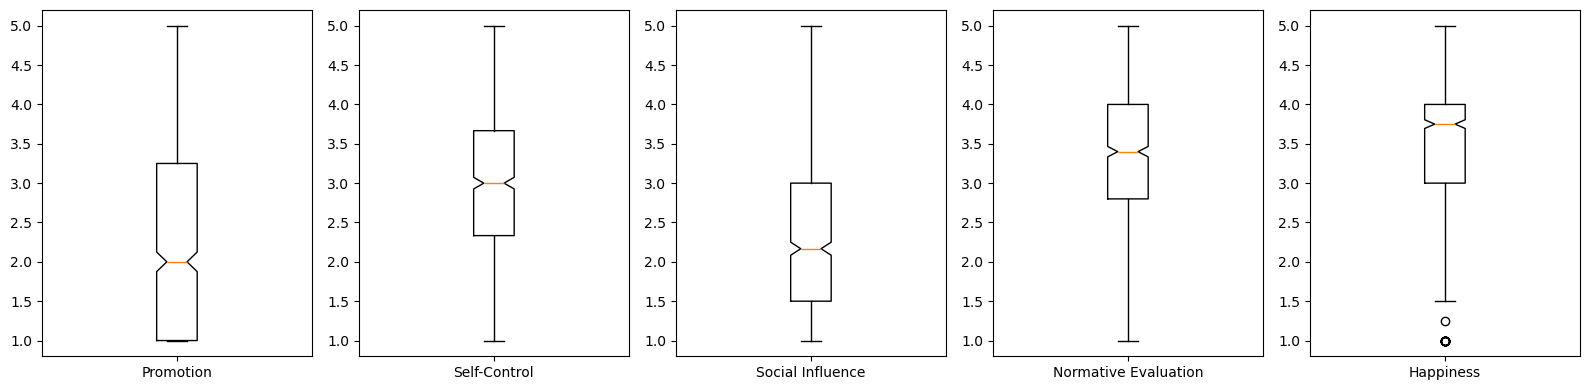

In [6]:
fig, axs = plt.subplots(1, 5, figsize = (16,4), tight_layout = True)
axs[0].boxplot( df['P'], tick_labels = ['Promotion'], notch = True)
axs[1].boxplot( df['SC'], tick_labels = ['Self-Control'], notch = True)
axs[2].boxplot( df['SI'], tick_labels = ['Social Influence'], notch = True)
axs[3].boxplot( df['NE'], tick_labels = ['Normative Evaluation'], notch = True)
axs[4].boxplot( df['H'], tick_labels = ['Happiness'], notch = True)

plt.show()

Let's save the variables in easier-to-use variable names:

In [7]:
y    = df['IBB']
P = df['P']
SC = df['SC']
SI = df['SI']
NE = df['NE']
H = df['H']
G = df['Gender']
S = df['Status']
I = df['Income']

Let's create scatterplots for the DV (IBB) vs. each of the five IVs (Promotion, Self-Control, Social Influence, Normative Evaluation, Happiness) and CVs (Gender, Status, Income):

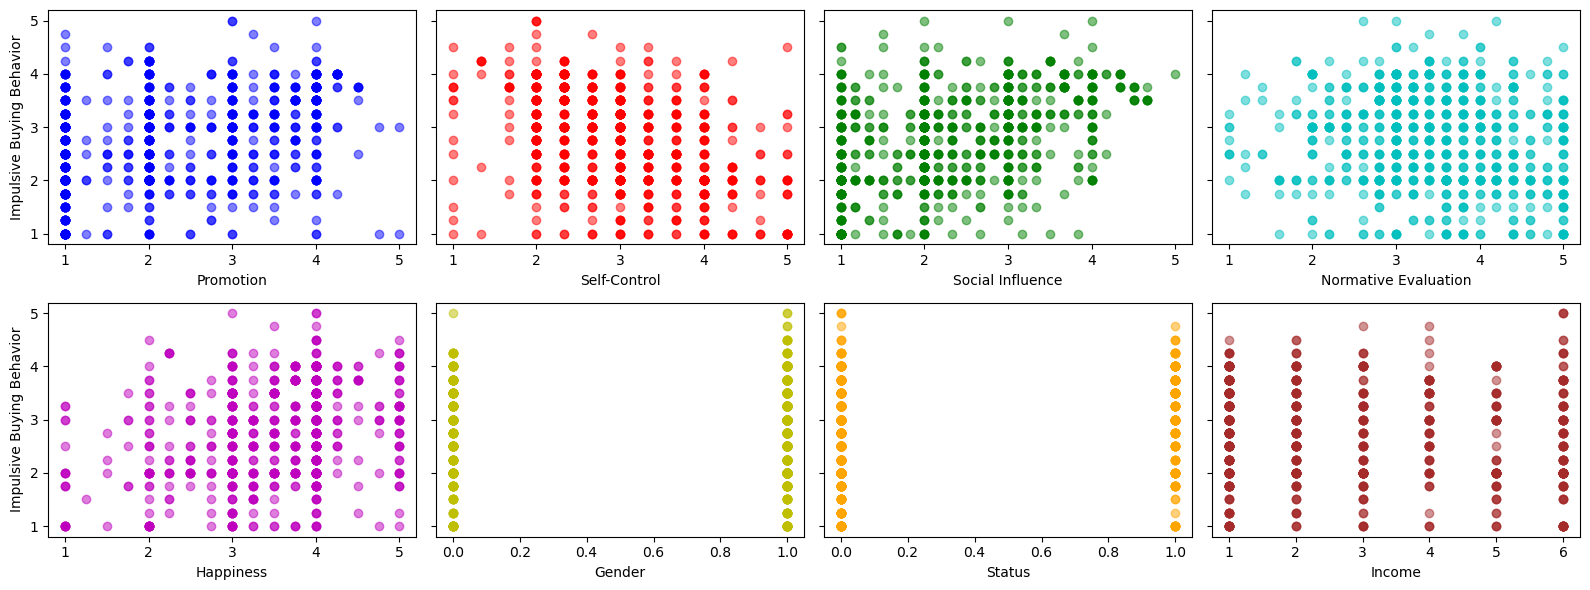

In [8]:
fig,axs = plt.subplots( 2, 4, figsize=(16,6), tight_layout=True )
axs[0, 0].scatter( P, y, alpha=0.5, color= 'b' )
axs[0, 1].scatter( SC, y, alpha=0.5, color= 'r' )
axs[0, 2].scatter( SI, y, alpha=0.5, color= 'g' )
axs[0, 3].scatter( NE, y, alpha=0.5, color= 'c' )
axs[1, 0].scatter( H, y, alpha=0.5, color= 'm' )
axs[1, 1].scatter( G, y, alpha=0.5, color= 'y' )
axs[1, 2].scatter( S, y, alpha=0.5, color= 'orange' )
axs[1, 3].scatter( I, y, alpha=0.5, color= 'brown' )

xlabels = 'Promotion', 'Self-Control', 'Social Influence', 'Normative Evaluation', 'Happiness', 'Gender', 'Status', 'Income'
[ax.set_xlabel(s) for ax,s in zip(axs.ravel(),xlabels)]
axs[0, 0].set_ylabel('Impulsive Buying Behavior')
axs[1, 0].set_ylabel('Impulsive Buying Behavior')
[ax.set_yticklabels([]) for ax in axs[:, 1:].ravel()]
plt.show()

Next let's add regression lines and correlation coefficients to each plot:

In [9]:
def corrcoeff(x, y):
    r = np.corrcoef(x, y)[0,1]
    return r

def plot_regression_line(ax, x, y, **kwargs):
    a,b   = np.polyfit(x, y, deg=1)
    x0,x1 = min(x), max(x)
    y0,y1 = a*x0 + b, a*x1 + b
    ax.plot([x0,x1], [y0,y1], **kwargs)


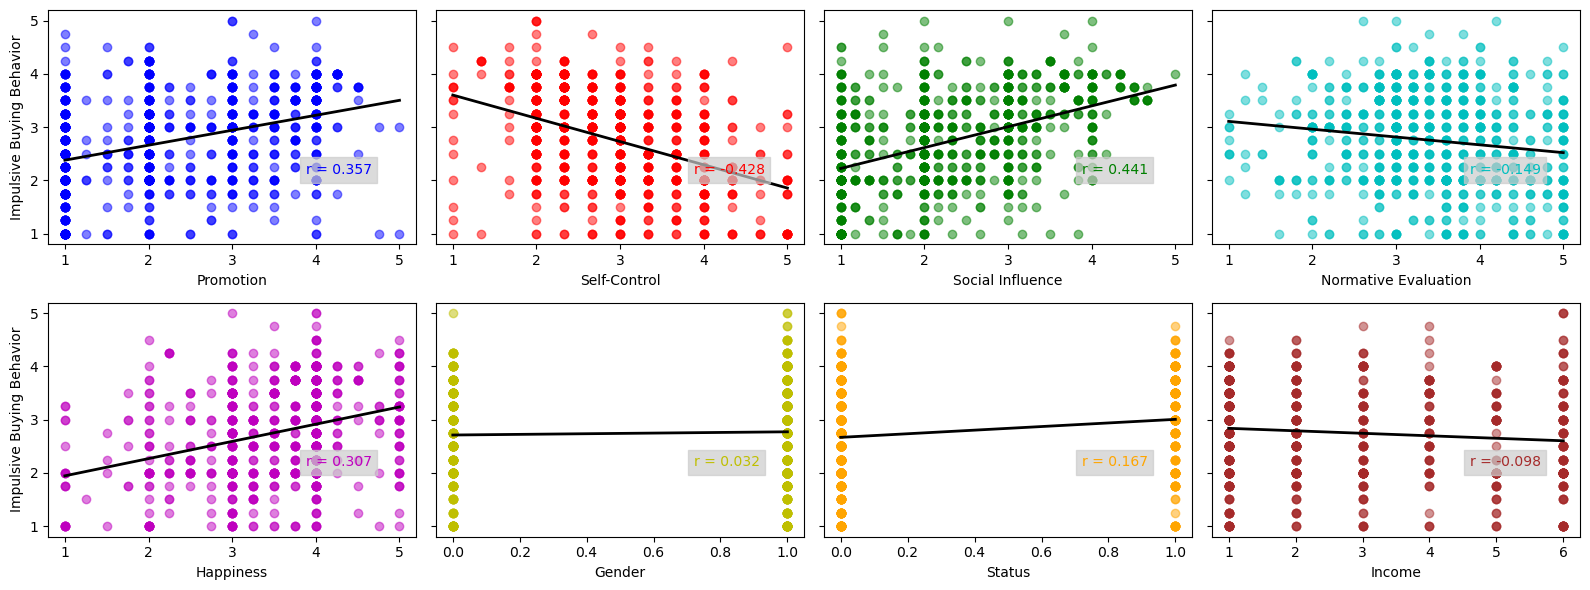

In [10]:
    
fig,axs = plt.subplots( 2, 4, figsize=(16,6), tight_layout=True )
ivs     = [P, SC, SI, NE, H, G, S, I]
colors  = 'b', 'r', 'g', 'c', 'm', 'y', 'orange', 'brown'
for ax,x,c in zip(axs.ravel(), ivs, colors):
    ax.scatter( x, y, alpha=0.5, color=c )
    plot_regression_line(ax, x, y, color='k', ls='-', lw=2)
    r   = corrcoeff(x, y)
    ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

xlabels = 'Promotion', 'Self-Control', 'Social Influence', 'Normative Evaluation', 'Happiness', 'Gender', 'Status', 'Income'
[ax.set_xlabel(s) for ax,s in zip(axs.ravel(),xlabels)]
axs[0, 0].set_ylabel('Impulsive Buying Behavior')
axs[1, 0].set_ylabel('Impulsive Buying Behavior')
[ax.set_yticklabels([]) for ax in axs[:, 1:].ravel()]
plt.show()

The correlation coefficients are all relatively low, suggesting no clear linear correlation between the DV and the IVs.

For the CVs, we see that they show little correlation with the DV. This proves that the CVs are the relevant controllers.

Let's now assemble all results into a single figure for reporting purposes:

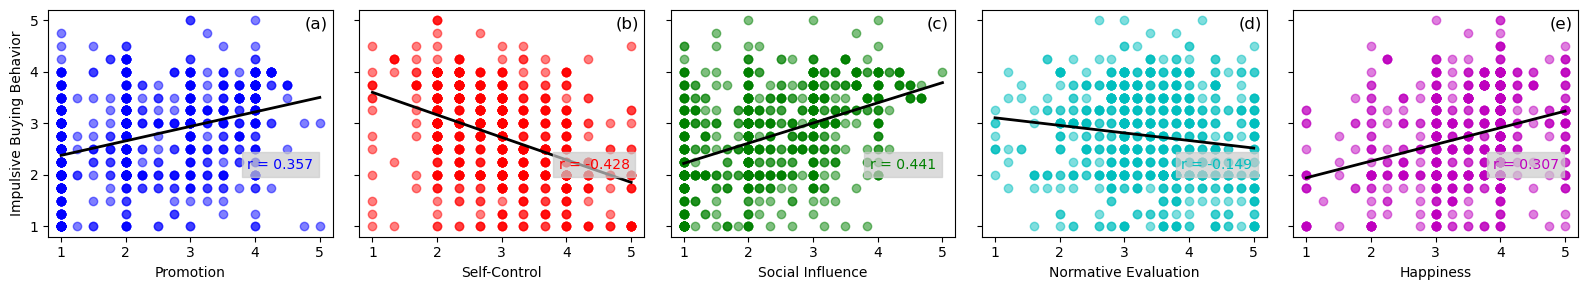

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [11]:
def plot_descriptive():
    
    ig,axs = plt.subplots( 1, 5, figsize=(16,3), tight_layout=True )
    ivs     = [P, SC, SI, NE, H]
    colors  = 'b', 'r', 'g', 'c', 'm'
    for ax,x,c in zip(axs, ivs, colors):
        ax.scatter( x, y, alpha=0.5, color=c )
        plot_regression_line(ax, x, y, color='k', ls='-', lw=2)
        r   = corrcoeff(x, y)
        ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

    xlabels = 'Promotion', 'Self-Control', 'Social Influence', 'Normative Evaluation', 'Happiness'
    [ax.set_xlabel(s) for ax,s in zip(axs.ravel(),xlabels)]
    axs[0].set_ylabel('Impulsive Buying Behavior')
    [ax.set_yticklabels([]) for ax in axs[1:]]


    panel_labels = 'a', 'b', 'c', 'd', 'e'
    [ax.text(0.90, 0.92, f'({s})', size=12, transform=ax.transAxes)  for ax,s in zip(axs, panel_labels)]
    plt.show()
    
    display_title('Correlations amongst main variables.', pref='Figure', num=1)

    
plot_descriptive()